In [1]:
from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set, elements
import os
from data import items, item_sets
import json

In [2]:
from datetime import datetime
config = {
    "optimizer" : {
        "path" : f"./outputs/sacri-omni-crit-absweapon/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}",
        "language": "es",
        "population_size": 300,
        "num_parents_mating": 100, # Number of parents to mate, usually 1/3 of population size
        "num_generations": 200,
        "mutation_rate": 0.05,
        "crossover_rate": 0.8,
        "parent_selection_type": "tournament",  # Tournament Selection
        "tournament_size": 3,
        "exclusions": {
            "items": [6894,
                        6895,
                        3080,
                        9031,
                        6980, # Vulbis
                        13344, # Dolmanax
                        ]  # Excluded items
        },
        "inclusions": {
            "items": [
                # 14093, # Botas kuko
                # 18718, # Escudo kuko
                # 14092, # Anillo kuko
                # 8993, # Espada maldita
                7754, # Dofus ocre
            ]
        },
        "preferences": {
            "lower": {
                12: {
                    "target": 12,  # AP
                    "strength": 0.9,  # Penalty for not meeting the target
                },
                8: {
                    "target": 6,  # MP
                    "strength": 0.9,  # Penalty for not meeting the target
                },
                29: {
                    "target": 80,  # Crit
                    "strength": 0.75,  # Penalty for not meeting the target
                },
                9: {
                    "target": 4000,  # Vit
                    "strength": 0.5,  # Penalty for not meeting the target
                },
                34 : {
                    "target": 15, # %res neutral
                    "strength": 0.1,  # Penalty for not meeting the target
                },
                37 : {
                    "target": 15, # %res fire
                    "strength": 0.1,  # Penalty for not meeting the target
                },
                16 : {
                    "target": 15, # %res air
                    "strength": 0.1,  # Penalty for not meeting the target
                },
                17 : {
                    "target": 15, # %res water
                    "strength": 0.1,  # Penalty for not meeting the target
                },
                63 : {
                    "target": 15, # %res range
                    "strength": 0.1,  # Penalty for not meeting the target
                }
            },
            "upper": {}
        },

        "level_offset": 10,  # Level offset for items
        "objective": "weapon",  # Objective to optimize, can be "weapon" or "elements"
        "normalize_by_apcost" : False # If False, only care about absolute damage regardless of AP cost
    },
    "character": {
        "level": 200,
        "scrolled": True,
        "exo": {
            12:1, # Exo AP
            8:1 # Exo MP
            },  
        "distributed_points": {
            9: 595,  # Vitality
        },
        "elements" : [
            36, # Agility,
            22, # Chance
            13, # Intelligence
            45  # Strength
        ],
        "melee" : True,
        "ranged" : False
    }
}

# Insert a list of initial user guesses, e.g., current set to use in optimization
initial_options = [
    [
    8993, # Espada
    13641, 13642, # Noai
    14161, 14162, 14169, # Charlatan
    14092, 14093, 18718, # Kuko
    13673, # Lokulto
    739, 694, 7754, 737, 7043, 17078 # Dofus
    ]
]
config["optimizer"]["initial_options"] = initial_options

if not os.path.exists(config["optimizer"]["path"]):
    os.makedirs(config["optimizer"]["path"], exist_ok=True)

with open(config["optimizer"]["path"] + '/config.json', 'w') as file:
    json.dump(config, file, indent=4)

In [3]:
import pandas as pd

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
    dct[k].update({i:j for i,j in v['type'].items() if i not in dct[k]})
Items = pd.DataFrame.from_dict(dct, orient='index')

In [15]:
Items[Items['categoryId']==0]

,name,set,level,id,itemTypeId,superTypeId,categoryId
33048,Dragopavo orquídeo y púrpura,NaN,60,331,247,12,0
28188,Cotas EsPM Vi Reemp,NaN,200,274,79,69,0
19846,Vueloceronte dorado y orquídeo,NaN,60,207,71,27,0
13796,Desvanecedor menor,NaN,50,151,23,13,0
14803,Botas nō,NaN,10,11,45,5,0
...,...,...,...,...,...,...,...
17909,Mulagua dorada y marfil,NaN,60,196,126,27,0
19589,Capa ardiente,Set ardiente,200,17,43,11,0
11631,Martillo de Piratalaya,Set del Roca Negra,156,7,42,2,0
953,Capa de tofu loco,NaN,36,17,43,11,0


In [7]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 1771
Total item sets: 161
Total pools:
   16 with sizes [73, 75, 82, 82, 65, 83, 46, 93, 72, 453, 1, 293, 293, 293, 293, 293]
Total combinations: 10^31.78


In [5]:
solutions = opt.optimize(islands = 12,
                          max_workers = 4)

/Users/jdtibochab/other/dofus-set-optimizer/.venv/lib/python3.12/site-packages/pygad/utils/validation.py:1914: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/other/dofus-set-optimizer/.venv/lib/python3.12/site-packages/pygad/utils/validation.py:1914: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/other/dofus-set-optimizer/.venv/lib/python3.12/site-packages/pygad/utils/validation.py:1

## Analysis

In [6]:
from analysis import Analyzer
analyzer = Analyzer(opt, solutions)
analyzer.run_analysis()

Number of candidate solutions: 121


In [7]:
analyzer.report_extended_results()

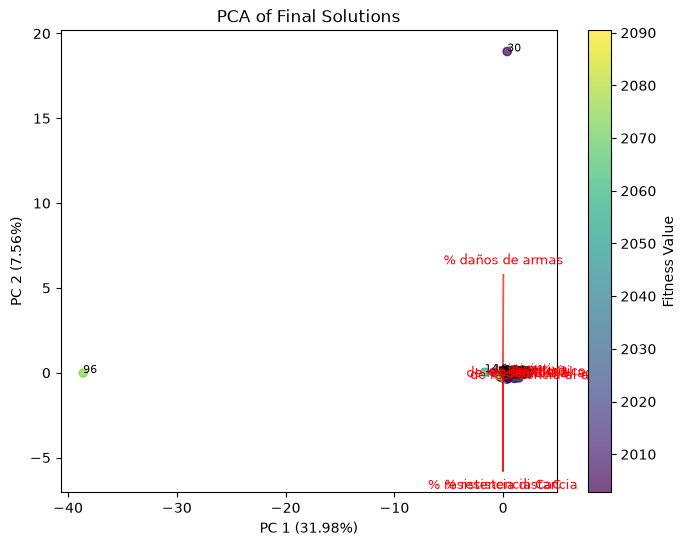

In [8]:
analyzer.plot_pca()

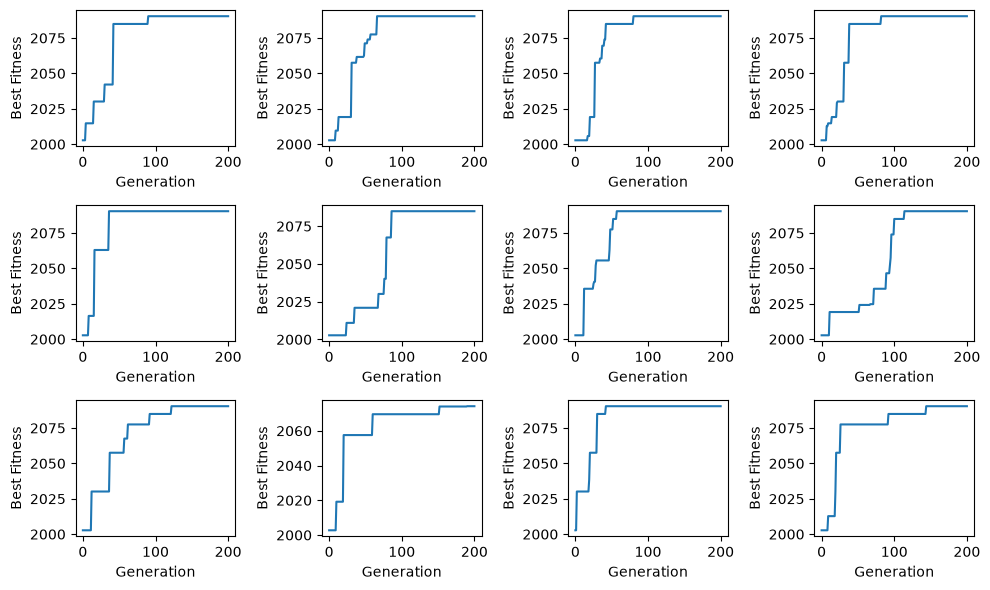

In [9]:
analyzer.report_generations()

In [10]:
assert False

AssertionError: 

In [8]:
Items

,name,set,level,id,itemTypeId,superTypeId,categoryId
30114,Escudo de Lokus,NaN,1,248,19,22,5
31694,Máscara de seguridad,Set cosmético de inventor acorazado,1,246,6,22,5
33870,Alma capturada: Abrakeponerse el Optimista,NaN,90,328,243,6,1
33484,Elixir de abrevadero,NaN,175,326,244,9,2
8490,Fémur de Sfinter Cell,NaN,150,47,2,9,2
...,...,...,...,...,...,...,...
32456,Capa de Gúltar,Set cosmético de Gúltar,1,247,18,22,5
12399,Trampa del maestro cazador,NaN,1,147,138,14,3
13098,Casco de chafer primitivo,NaN,36,164,51,9,2
8801,Tejido de stropajo,NaN,92,55,9,9,2


In [9]:
# Current
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 18043 # Dofus
                 ],
                 opt)
chr.fitness, chr.get_final_damage("weapon")

(2002.7399999999998, 2002.7399999999998)

In [10]:
Items.loc[chr.chromosome]

,name,set,level,id,itemTypeId,superTypeId,categoryId
8993,Espada maldita del gran Desangrador Guerrero,NaN,200,6,80,2,0
13641,Gorro de Noai Aludem,Set de Noai Aludem,198,16,27,10,0
13642,Anillo de Noai Aludem,Set de Noai Aludem,197,9,17,3,0
14161,Capa Ordiosera,Set de charlatán,200,17,43,11,0
14162,Cinto Dovencible,Set de charlatán,200,10,58,4,0
14169,Talismán Tira,Set de charlatán,200,1,33,1,0
14092,Anillo de kukoloide,Set de kukoloide,200,9,17,3,0
14093,Botas de kukoloide,Set de kukoloide,200,11,45,5,0
18718,Escudo de kukoloide,Set de kukoloide,200,82,87,7,0
13673,Lokulto,NaN,20,18,1,12,0


In [11]:
chr.totals_summary()

,description,value
0,Intercambiable:,0.0
8,PM,6.0
9,vitalidad,4260.0
10,sabiduría,430.0
12,PA,12.0
13,inteligencia,620.0
14,de resistencia al fuego,35.0
15,de resistencia a la tierra,25.0
16,% resistencia al aire,45.0
17,% resistencia al agua,41.0


In [16]:
Items[Items["name"].str.contains("Dofus marf",case=False)]

,name,set,level,id,itemTypeId,superTypeId,categoryId
20128,Réplica del dofus Marfil,NaN,1,15,229,9,2
7115,Dofus Marfil,NaN,180,23,177,13,0


In [ ]:
Items[(Items["superTypeId"]==13) & (Items["name"].str.contains("Pris",case=False))]

,name,set,level,id,itemTypeId,superTypeId,categoryId
22004,Prisyingyang,NaN,200,217,124,13,0
22012,Prismacción brillante,NaN,200,217,124,13,0
21998,Pristrés iridiscente,NaN,200,217,124,13,0
22019,Prismausente,NaN,200,217,124,13,0
21451,Priscudo mate,NaN,200,217,124,13,0
22025,Prismazacote,NaN,200,217,124,13,0
22018,Caparapris,NaN,200,217,124,13,0
32164,Indespris,NaN,200,217,124,13,0
22015,Prisencia,NaN,200,217,124,13,0
22007,Pristeza,NaN,200,217,124,13,0


In [15]:
Items[(Items["superTypeId"].isin([13]))]

,name,set,level,id,itemTypeId,superTypeId,categoryId
13796,Desvanecedor menor,NaN,50,151,23,13,0
12630,Ralentizador mayor,NaN,150,151,23,13,0
20833,Dofus cacao,NaN,50,23,177,13,0
16292,Evasivo menor,NaN,50,151,23,13,0
12626,Desertor mediano,NaN,100,151,23,13,0
...,...,...,...,...,...,...,...
12624,Placador mayor,NaN,150,151,23,13,0
22021,Prismapoyo,NaN,200,217,124,13,0
12651,Acorazado de aire mayor,NaN,150,151,23,13,0
30453,Impetuoso,NaN,150,151,23,13,0


In [12]:
Items[(Items["superTypeId"].isin([9]))]

,name,set,level,id,itemTypeId,superTypeId,categoryId
33484,Elixir de abrevadero,NaN,175,326,244,9,2
8490,Fémur de Sfinter Cell,NaN,150,47,2,9,2
19111,Fragmento del mapa del Caballero de Hielo 5/8,NaN,200,175,4,9,2
11938,Cuero de golornado,NaN,190,56,109,9,2
7277,Gafas de kojonuki,NaN,130,164,51,9,2
...,...,...,...,...,...,...,...
14474,Sangre de wabbit lobo,NaN,120,228,72,9,2
32982,Mapa de Carter Pillar,NaN,180,174,155,9,2
23694,Picadillo de bruma,NaN,160,15,229,9,2
13098,Casco de chafer primitivo,NaN,36,164,51,9,2


In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary()

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)